In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = pd.read_csv("crop_yield.csv")

In [3]:
print("First 5 Rows:")
print(data.head())

print("\nLast 5 Rows:")
print(data.tail())


print("\nDataset Info:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

First 5 Rows:
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  

Last 5 Rows:
                Crop  Crop_Year       Season              State      Area  \
19684  Small millets       1998  Kharif                Nagaland    4000.0   
19685          Wheat       1998  Rabi            

In [4]:

print("\nMissing Values:")
print(data.isnull().sum())

cat_cols = ['Crop', 'Season', 'State']
num_cols = ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())


Missing Values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [5]:
le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

X = data[['Crop', 'Crop_Year', 'Season', 'State',
          'Area', 'Annual_Rainfall',
          'Fertilizer', 'Pesticide']]

In [6]:
y = data['Production']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [8]:
y_pred = model.predict(X_test)

print("\nModel Performance:")
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nSample Predictions:")
print(result.head(10))


Model Performance:
MSE : 707288764722603.2
R2 Score : 0.9906965467598191

Sample Predictions:
    Actual   Predicted
0     1010      244.06
1    10280    11480.97
2    44026    43884.22
3    27189    38631.15
4     4970     8576.06
5       94      229.66
6     7005     9399.85
7    11324    11612.32
8  2001900  1777325.47
9       52       28.03


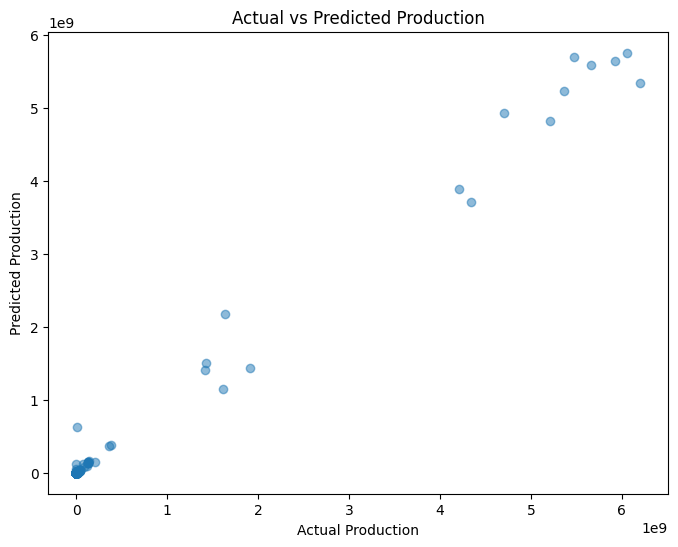

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")
plt.show()